# Computer Exercise 1.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — *First Programming Experiment*
> **풀이 일자**: Day 01
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Write and run a computer program that corresponds to the *Example: First* described on pp. 12–13 and interpret the results.

### 한국어 풀이용 정리
교재 본문의 **First Programming Experiment**(전진차분, forward difference)을 그대로 코드로 구현한 뒤,
스텝 크기 $h$를 점차 줄여 나가면서 미분 근삿값의 오차가 어떻게 변하는지 관찰하고 해석한다.

본문에 주어진 의사코드 (요지):

```text
program First
    integer i, n ← 30
    real error, y, x ← 0.5, h ← 1, emin ← 1
    for i ← 1 to n
        h ← 0.25 * h
        y ← (sin(x + h) − sin(x)) / h
        error ← |cos(x) − y|
        output i, h, y, error
        if error < emin then
            emin ← error;  imin ← i
        end if
    end for
    output imin, emin
end program First
```


## 2. 수학적 배경

### 2.1 전진차분(forward difference) 근사식
미분의 정의

$$
f'(x) \;=\; \lim_{h \to 0}\frac{f(x+h)-f(x)}{h}
$$

에서 극한을 떼고 유한한 $h$ 만큼 평가한 식

$$
D_h^+ f(x) \;\equiv\; \frac{f(x+h)-f(x)}{h}
$$

가 **전진차분 근사**이다.

### 2.2 절단오차 (truncation error)
Taylor 전개에 의해

$$
f(x+h) = f(x) + h f'(x) + \tfrac{h^2}{2} f''(\xi),\qquad \xi \in (x, x+h)
$$

이므로

$$
\frac{f(x+h)-f(x)}{h} = f'(x) + \tfrac{h}{2} f''(\xi).
$$

따라서 절단오차는

$$
E_{\text{trunc}}(h) \;=\; \tfrac{h}{2}\,|f''(\xi)| \;=\; \mathcal{O}(h).
$$

이론상 $h$가 작을수록 정확해야 한다.

### 2.3 반올림오차 (round-off error)
부동소수점 환경에서 $\sin(x+h)$와 $\sin(x)$는 각각 $\sim \varepsilon_{\text{mach}} \cdot |\sin(x)|$ 정도의 오차를 갖는다.
두 값을 빼면 *catastrophic cancellation* 으로 분자의 상대오차가 커지고, 또 $h$로 나누기 때문에

$$
E_{\text{round}}(h) \;\approx\; \frac{2\varepsilon_{\text{mach}}\,|f(x)|}{h} \;=\; \mathcal{O}(h^{-1}).
$$

### 2.4 총오차의 U자형 곡선
총오차 $E(h) \approx \tfrac{h}{2}|f''(\xi)| + 2\varepsilon_{\text{mach}}|f(x)|/h$ 를 $h$에 대해 미분해 0이 되게 두면

$$
h^* \;\approx\; 2\sqrt{\,\varepsilon_{\text{mach}}\,|f(x)|/|f''(x)|\,}.
$$

즉 **$h$를 무작정 줄이면 오히려 오차가 커진다.** 이 실험의 핵심 메시지가 이 U자형 곡선이다.


## 3. 풀이 흐름

1. **함수 선택**: $f(x) = \sin(x)$, 평가점 $x = 0.5$ — 본문과 동일.
2. **참값 (true derivative)**: $f'(x) = \cos(x)$ → `cos(0.5)`.
3. **반복**: $h_i = 4^{-i}$ for $i = 1, 2, \ldots, 30$.
   - 의사코드의 `h ← 0.25 * h`(초기 $h=1$)와 동치.
4. **각 $h_i$에 대해**:
   - 근사값 $y_i = (\sin(x+h_i) - \sin(x))/h_i$
   - 오차 $e_i = |\cos(x) - y_i|$
5. **최소오차 추적**: $e_i$가 갱신될 때마다 `emin`, `imin`을 업데이트.
6. **결과 표 출력**: $(i,\;h_i,\;y_i,\;e_i)$.
7. **시각화**: $\log_{10} h$ vs $\log_{10} e$ 그래프로 U자형 확인.
8. **해석**:
   - $h$가 클 때는 절단오차 $\mathcal{O}(h)$ 가 지배 → 기울기 $+1$.
   - $h$가 매우 작을 때는 반올림오차 $\mathcal{O}(h^{-1})$ 가 지배 → 기울기 $-1$.
   - 최적 $h^*$ 부근에서 오차가 최소.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 본문 설정
x      = 0.5
n_max  = 30
true_d = np.cos(x)             # f'(x) = cos(x)

# 의사코드와 동일하게 h_i = 4^{-i}, i = 1..30
i_arr = np.arange(1, n_max + 1)
h_arr = 0.25 ** i_arr

# 전진차분 근사
y_arr = (np.sin(x + h_arr) - np.sin(x)) / h_arr
err   = np.abs(true_d - y_arr)

df = pd.DataFrame({
    "i": i_arr,
    "h": h_arr,
    "y (approx f'(x))": y_arr,
    "|cos(x) - y|": err,
})
pd.set_option("display.float_format", lambda v: f"{v:.10g}")
df

,i,h,y (approx f'(x)),|cos(x) - y|
0,1,0.25,0.8088528857,0.06872967621
1,2,0.0625,0.8620341589,0.01554840298
2,3,0.015625,0.8738014176,0.003781144308
3,4,0.00390625,0.8766439533,0.0009386086206
4,5,0.0009765625,0.8773483279,0.0002342339707
5,6,0.000244140625,0.8775240295,5.853234294e-05
6,7,6.103515625e-05,0.8775679304,1.463145137e-05
7,8,1.525878906e-05,0.8775789041,3.657762059e-06
8,9,3.814697266e-06,0.8775816475,9.144386386e-07
9,10,9.536743164e-07,0.8775823333,2.286068739e-07


In [2]:
imin = int(np.argmin(err) + 1)        # 1-based
emin = float(err.min())
hmin = float(h_arr[imin - 1])

print(f"최소 오차 발생: i = {imin},  h = {hmin:.3e},  |error| = {emin:.3e}")
print(f"true f'(x) = cos({x}) = {true_d:.16f}")

최소 오차 발생: i = 14,  h = 3.725e-09,  |error| = 3.060e-09
true f'(x) = cos(0.5) = 0.8775825618903728


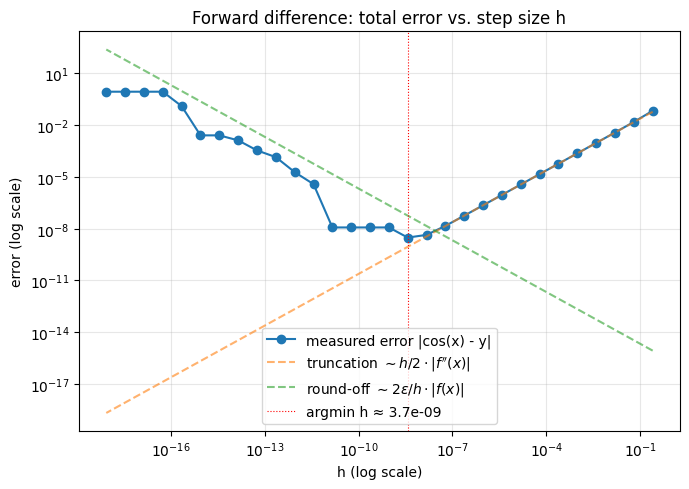

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(h_arr, err, "o-", label="measured error |cos(x) - y|")

# 이론 슬로프 보조선: O(h) 와 O(1/h)
h_ref = h_arr
trunc_ref = 0.5 * h_ref * abs(np.sin(x))                     # h/2 * |f''(ξ)| ≈ h/2*|sin(x)|
round_ref = 2 * np.finfo(float).eps * abs(np.sin(x)) / h_ref # 2 ε_mach |f(x)| / h
ax.loglog(h_ref, trunc_ref, "--", alpha=0.6, label=r"truncation $\sim h/2 \cdot |f''(x)|$")
ax.loglog(h_ref, round_ref, "--", alpha=0.6, label=r"round-off $\sim 2\varepsilon / h \cdot |f(x)|$")

ax.axvline(hmin, color="red", lw=0.8, ls=":", label=f"argmin h ≈ {hmin:.1e}")
ax.set_xlabel("h (log scale)")
ax.set_ylabel("error (log scale)")
ax.set_title("Forward difference: total error vs. step size h")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 결과 해석

- $h$가 큰 영역(예: $h = 0.25, 0.0625$)에서는 오차가 **$h$에 비례**해 줄어든다 → 절단오차 지배 영역.
- $h$가 매우 작은 영역(예: $h \lesssim 10^{-8}$)에서는 오차가 **$1/h$ 처럼** 다시 커진다 → 반올림오차 지배 영역.
- 두 곡선의 교점 근처(이론상 $h^* \sim \sqrt{\varepsilon_{\text{mach}}} \approx 10^{-8}$) 에서 오차가 최소.
- 실험에서 얻은 `imin`, `hmin`이 위 이론값과 잘 부합하는지 확인.

### 결론
> **"$h \to 0$ 이면 미분이 정확해진다"는 수학적 직관은 부동소수점 산술에서는 깨진다.**
> 절단오차와 반올림오차의 **trade-off** 때문에 어느 적절한 $h^*$ 부근에서 오차가 최소가 된다.
> 이것이 1.1절 *First Programming Experiment* 의 핵심 메시지이며,
> 이후 §4.3 (Estimating Derivatives)에서 *Richardson extrapolation* 같은 개선 기법으로 다시 다룬다.

### 다음 문제 연결
- **CE 1.1.2**: 같은 실험을 다른 함수 $1/x,\ \log x,\ e^x,\ \tan x,\ \cosh x,\ x^3-23x$ 등에 대해 반복.
- **CE 1.1.3**: **중심차분(central difference)** 으로 같은 분석 — 절단오차가 $\mathcal{O}(h^2)$ 로 더 빨리 줄어든다.
